# Preamble

In [1]:
import pandas as pd
import numpy as np

import math
from collections import Counter

# Statistics
from scipy import stats
from scipy.stats import normaltest , mannwhitneyu ,levene,chi2_contingency ,  pearsonr, spearmanr
from statsmodels.stats.oneway import anova_oneway

import pingouin as pg


# Machine Learning
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score , accuracy_score , confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split , StratifiedKFold
from sklearn.preprocessing import RobustScaler , StandardScaler , OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from imblearn.ensemble import BalancedRandomForestClassifier , BalancedBaggingClassifier
from sklearn.base import clone
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE , SMOTENC

#visualisation
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customer = pd.read_csv('Raw_Data/customer.csv')
order = pd.read_csv('Raw_Data/order.csv')
order_detail = pd.read_csv('Raw_Data/order_detail.csv')
product = pd.read_csv('Raw_Data/product.csv')
returned = pd.read_csv('Raw_Data/returned.csv')
shipping = pd.read_csv('Raw_Data/shipping.csv')

# Preprocessing

In [3]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 1589 entries, 0 to 1588
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Customer ID    1589 non-null   str  
 1   Customer Name  1589 non-null   str  
 2   Segment        1589 non-null   str  
dtypes: str(3)
memory usage: 82.9 KB


In [4]:
order.info()

<class 'pandas.DataFrame'>
RangeIndex: 25033 entries, 0 to 25032
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Order ID        25033 non-null  str  
 1   Customer ID     25033 non-null  str  
 2   Order Priority  25033 non-null  str  
 3   Order Date      25033 non-null  str  
 4   Market          25033 non-null  str  
dtypes: str(5)
memory usage: 2.1 MB


In [5]:
order_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         49670 non-null  int64  
 1   Order ID       49670 non-null  str    
 2   Product ID     49670 non-null  str    
 3   Sales          49670 non-null  float64
 4   Quantity       49670 non-null  int64  
 5   Discount       49670 non-null  float64
 6   Profit         49670 non-null  float64
 7   Shipping Cost  49670 non-null  float64
dtypes: float64(4), int64(2), str(2)
memory usage: 4.4 MB


In [6]:
product.info()

<class 'pandas.DataFrame'>
RangeIndex: 10246 entries, 0 to 10245
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Product ID    10246 non-null  str  
 1   Product Name  10246 non-null  str  
 2   Category      10246 non-null  str  
 3   Sub-Category  10246 non-null  str  
dtypes: str(4)
memory usage: 983.2 KB


In [7]:
returned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1172 entries, 0 to 1171
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Order ID  1172 non-null   str  
dtypes: str(1)
memory usage: 25.3 KB


In [8]:
shipping.info()

<class 'pandas.DataFrame'>
RangeIndex: 25033 entries, 0 to 25032
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Shipping ID  25033 non-null  int64
 1   Order ID     25033 non-null  str  
 2   Ship Date    25033 non-null  str  
 3   Ship Mode    25033 non-null  str  
 4   City         25033 non-null  str  
 5   State        25033 non-null  str  
 6   Country      25033 non-null  str  
 7   Region       25033 non-null  str  
dtypes: int64(1), str(7)
memory usage: 3.4 MB


In [9]:
customer.head()

,Customer ID,Customer Name,Segment
0,AA-10315,Alex Avila,Consumer
1,AA-10375,Allen Armold,Consumer
2,AA-10480,Andrew Allen,Consumer
3,AA-10645,Anna Andreadi,Consumer
4,AA-315,Alex Avila,Consumer


In [10]:
order.head()

,Order ID,Customer ID,Order Priority,Order Date,Market
0,AE-2011-9160,PO-8865,Medium,2011-10-03 00:00:00,EMEA
1,AE-2013-1130,EB-4110,High,2013-10-14 00:00:00,EMEA
2,AE-2013-1530,MY-7380,High,2013-12-31 00:00:00,EMEA
3,AE-2014-2840,PG-8820,Critical,2014-11-05 00:00:00,EMEA
4,AE-2014-3830,GH-4665,Medium,2014-12-13 00:00:00,EMEA


In [11]:
order_detail.head()

,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787


In [12]:
product.head()

,Product ID,Product Name,Category,Sub-Category
0,FUR-ADV-10000002,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings
1,FUR-ADV-10000108,"Advantus Clock, Erganomic",Furniture,Furnishings
2,FUR-ADV-10000183,"Advantus Photo Frame, Black",Furniture,Furnishings
3,FUR-ADV-10000188,"Advantus Stacking Tray, Erganomic",Furniture,Furnishings
4,FUR-ADV-10000190,"Advantus Frame, Duo Pack",Furniture,Furnishings


In [13]:
returned.head()

,Order ID
0,CA-2011-100762
1,CA-2011-100867
2,CA-2011-102652
3,CA-2011-103373
4,CA-2011-103744


In [14]:
shipping.head()

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
0,21043,CA-2012-124891,2012-07-31 00:00:00,Same Day,New York City,New York,United States,East
1,21044,IN-2013-77878,2013-02-07 00:00:00,Second Class,Wollongong,New South Wales,Australia,Oceania
2,21045,IN-2013-71249,2013-10-18 00:00:00,First Class,Brisbane,Queensland,Australia,Oceania
3,21046,ES-2013-1579342,2013-01-30 00:00:00,First Class,Berlin,Berlin,Germany,Central
4,21047,SG-2013-4320,2013-11-06 00:00:00,Same Day,Dakar,Dakar,Senegal,Africa


In [15]:
customer.describe()

,Customer ID,Customer Name,Segment
count,1589,1589,1589
unique,1589,795,3
top,AA-10315,Alex Avila,Consumer
freq,1,2,817


In [16]:
order.describe()

,Order ID,Customer ID,Order Priority,Order Date,Market
count,25033,25033,25033,25033,25033
unique,25033,1589,4,1428,7
top,AE-2011-9160,PO-18850,Medium,2014-11-25 00:00:00,APAC
freq,1,41,14344,59,5437


In [17]:
order_detail.describe()

,Row ID,Sales,Quantity,Discount,Profit,Shipping Cost
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,25763.380974,243.840355,3.470787,0.143070,28.392264,26.041125
std,14838.084164,485.963091,2.274854,0.212046,172.399520,56.870281
min,1.000000,0.444000,1.000000,0.000000,-6599.980000,0.002000
25%,12749.250000,30.384000,2.000000,0.000000,0.000000,2.580000
50%,26073.500000,83.970000,3.000000,0.000000,9.154000,7.660000
75%,38522.750000,247.830000,5.000000,0.200000,36.266400,23.969000
max,51290.000000,22638.500000,14.000000,0.850000,8399.980000,933.570000


In [18]:
product.describe()

,Product ID,Product Name,Category,Sub-Category
count,10246,10246,10246,10246
unique,10246,3662,3,17
top,FUR-ADV-10000002,Staples,Office Supplies,Paper
freq,1,45,5674,779


In [19]:
returned.describe()

,Order ID
count,1172
unique,1172
top,CA-2011-100762
freq,1


In [20]:
shipping.describe(include='all')

,Shipping ID,Order ID,Ship Date,Ship Mode,City,State,Country,Region
count,25033.00000,25033,25033,25033,25033,25033,25033,25033
unique,NaN,25033,1464,4,3590,1089,147,13
top,NaN,CA-2012-124891,2014-11-17 00:00:00,Standard Class,New York City,California,United States,Central
freq,NaN,1,54,15011,448,1016,4990,5238
mean,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7226.54898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,21043.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,27301.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,33559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,39817.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
customer['Customer Name'].duplicated().sum()

np.int64(794)

In [22]:
canonical_lookup = customer.groupby('Customer Name')['Customer ID'].first().to_dict()

In [23]:
id_to_name = customer.set_index('Customer ID')['Customer Name'].to_dict()
id_to_canonical = {cid: canonical_lookup[name] for cid, name in id_to_name.items()}

In [24]:
order['Customer ID'] = order['Customer ID'].map(id_to_canonical).fillna(order['Customer ID'])

In [25]:
customer = customer.drop_duplicates(subset=['Customer Name'], keep='first')

In [26]:
customer.describe()

,Customer ID,Customer Name,Segment
count,795,795,795
unique,795,795,3
top,AA-10315,Alex Avila,Consumer
freq,1,1,409


In [27]:
returned["Returned"] = 1

In [28]:
df = order_detail.merge(order, on="Order ID", how="left")
df = df.merge(product, on="Product ID", how="left")
df = df.merge(customer, on="Customer ID", how="left")
df = df.merge(shipping, on="Order ID", how="left")
df = df.merge(returned , on="Order ID" , how="left")

In [29]:
df

,Row ID,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost,Customer ID,Order Priority,...,Customer Name,Segment,Shipping ID,Ship Date,Ship Mode,City,State,Country,Region,Returned
0,1,MX-2014-143658,OFF-LA-10002782,13.08,3,0.0,4.56,1.033,SC-10575,Medium,...,Sonia Cooley,Consumer,44634,2014-10-06 00:00:00,Standard Class,Mexico City,Distrito Federal,Mexico,North,NaN
1,2,MX-2012-155047,FUR-FU-10004015,252.16,8,0.0,90.72,13.449,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
2,3,MX-2012-155047,FUR-BO-10002352,193.28,2,0.0,54.08,9.627,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
3,4,MX-2012-155047,OFF-BI-10004428,35.44,4,0.0,4.96,1.371,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
4,5,MX-2012-155047,OFF-AR-10004594,71.60,2,0.0,11.44,3.787,KW-16570,Medium,...,Kelly Williams,Consumer,34096,2012-10-20 00:00:00,Standard Class,Dos Quebradas,Risaralda,Colombia,South,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49665,51286,HU-2012-7730,OFF-AVE-10004570,11.07,1,0.0,3.42,1.980,NF-18385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN
49666,51287,HU-2012-7730,TEC-LOG-10004419,61.44,2,0.0,18.42,13.020,NF-18385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN
49667,51288,HU-2012-7730,OFF-BOS-10002705,80.52,4,0.0,20.88,8.780,NF-18385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN
49668,51289,HU-2012-7730,OFF-ENE-10004132,130.44,4,0.0,33.84,18.970,NF-18385,High,...,Natalie Fritzler,Consumer,32078,2012-09-07 00:00:00,First Class,Budapest,Budapest,Hungary,EMEA,NaN


In [30]:
df['Row ID'].unique()

array([    1,     2,     3, ..., 51288, 51289, 51290], shape=(49670,))

In [31]:
df.drop(columns="Row ID" , inplace=True)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        49670 non-null  str    
 1   Product ID      49670 non-null  str    
 2   Sales           49670 non-null  float64
 3   Quantity        49670 non-null  int64  
 4   Discount        49670 non-null  float64
 5   Profit          49670 non-null  float64
 6   Shipping Cost   49670 non-null  float64
 7   Customer ID     49670 non-null  str    
 8   Order Priority  49670 non-null  str    
 9   Order Date      49670 non-null  str    
 10  Market          49670 non-null  str    
 11  Product Name    49670 non-null  str    
 12  Category        49670 non-null  str    
 13  Sub-Category    49670 non-null  str    
 14  Customer Name   49670 non-null  str    
 15  Segment         49670 non-null  str    
 16  Shipping ID     49670 non-null  int64  
 17  Ship Date       49670 non-null  str    
 1

In [33]:
df["Returned"] = df["Returned"].fillna(0)

In [34]:
df.describe()

,Sales,Quantity,Discount,Profit,Shipping Cost,Shipping ID,Returned
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,243.840355,3.470787,0.143070,28.392264,26.041125,31632.081639,0.059996
std,485.963091,2.274854,0.212046,172.399520,56.870281,6964.662856,0.237482
min,0.444000,1.000000,0.000000,-6599.980000,0.002000,21043.000000,0.000000
25%,30.384000,2.000000,0.000000,0.000000,2.580000,25564.000000,0.000000
50%,83.970000,3.000000,0.000000,9.154000,7.660000,30862.000000,0.000000
75%,247.830000,5.000000,0.200000,36.266400,23.969000,37182.750000,0.000000
max,22638.500000,14.000000,0.850000,8399.980000,933.570000,46075.000000,1.000000


In [35]:
df = df.astype({
    "Quantity": "int8",
    "Shipping ID": "int32",
    "Sales": "float32",
    "Discount": "float32",
    "Profit": "float32",
    "Shipping Cost": "float32",
    "Returned": "int8",
})

In [36]:
category_dict = {
    "Order Priority": "category",
    "Market": "category",
    "Category": "category",
    "Sub-Category": "category",
    "Segment": "category",
    "Ship Mode": "category",
    "City": "category",
    "State": "category",
    "Country": "category",
    "Region": "category",
}

df = df.astype(category_dict)

In [37]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        49670 non-null  str           
 1   Product ID      49670 non-null  str           
 2   Sales           49670 non-null  float32       
 3   Quantity        49670 non-null  int8          
 4   Discount        49670 non-null  float32       
 5   Profit          49670 non-null  float32       
 6   Shipping Cost   49670 non-null  float32       
 7   Customer ID     49670 non-null  str           
 8   Order Priority  49670 non-null  category      
 9   Order Date      49670 non-null  datetime64[us]
 10  Market          49670 non-null  category      
 11  Product Name    49670 non-null  str           
 12  Category        49670 non-null  category      
 13  Sub-Category    49670 non-null  category      
 14  Customer Name   49670 non-null  str           
 15  Segment      

In [39]:
numeric_columns = ['Sales' , 'Quantity' , 'Discount' , 'Profit' , 'Shipping Cost']

In [40]:
categorical_columns = ["Order Priority" ,
"Market" , 
"Category" , 
"Sub-Category" ,
"Segment" , 
"Ship Mode" ,
"City" , 
"State" , 
"Country" , 
"Region" ,
"Returned", ]

## Duplicates

In [41]:
df.duplicated().sum()

np.int64(0)

## Nan

In [42]:
def nan_percentage(df: pd.DataFrame) -> pd.DataFrame:
    total_rows = len(df)
    missing_count = [df[col].isna().sum() for col in df.columns]
    nan_pct = [(df[col].isna().sum() / total_rows) * 100 for col in df.columns]
    result = pd.DataFrame({"Missing Count": missing_count, "Nan Percent": nan_pct}, index=df.columns)
    return result.sort_values(by="Nan Percent", ascending=False)

In [43]:
nan_percentage(df)

,Missing Count,Nan Percent
Order ID,0,0.0
Product ID,0,0.0
Sales,0,0.0
Quantity,0,0.0
Discount,0,0.0
Profit,0,0.0
Shipping Cost,0,0.0
Customer ID,0,0.0
Order Priority,0,0.0
Order Date,0,0.0


# EDA

## Normality

In [44]:
def normality_checker(df, columns=None, alpha=0.05) -> pd.DataFrame:
    
    if columns is None:
        columns = df.select_dtypes(include='number').columns
    
    results = []
    
    for col in columns:
        clean_data = df[col].dropna()
        n = len(clean_data)
        
        if n < 3:
            results.append([col, n, None, "Not enough data"])
            continue
        
        stat, p_value = normaltest(clean_data)
        
        result = "Normal" if p_value > alpha else "Not normal"
        
        results.append([col, n, p_value, result])
    
    result_df = pd.DataFrame(
        results,
        columns=["Column", "Sample Size", "p-value", "Result"]
    )
    
    return result_df

In [45]:
normality_checker(df)

,Column,Sample Size,p-value,Result
0,Sales,49670,0.0,Not normal
1,Quantity,49670,0.0,Not normal
2,Discount,49670,0.0,Not normal
3,Profit,49670,0.0,Not normal
4,Shipping Cost,49670,0.0,Not normal
5,Shipping ID,49670,0.0,Not normal
6,Returned,49670,0.0,Not normal


In [46]:
df.groupby("Order ID").size().describe()

count    25033.000000
mean         1.984181
std          1.405625
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         14.000000
dtype: float64

In [47]:
df["Product ID"].shape

(49670,)

## Visualization

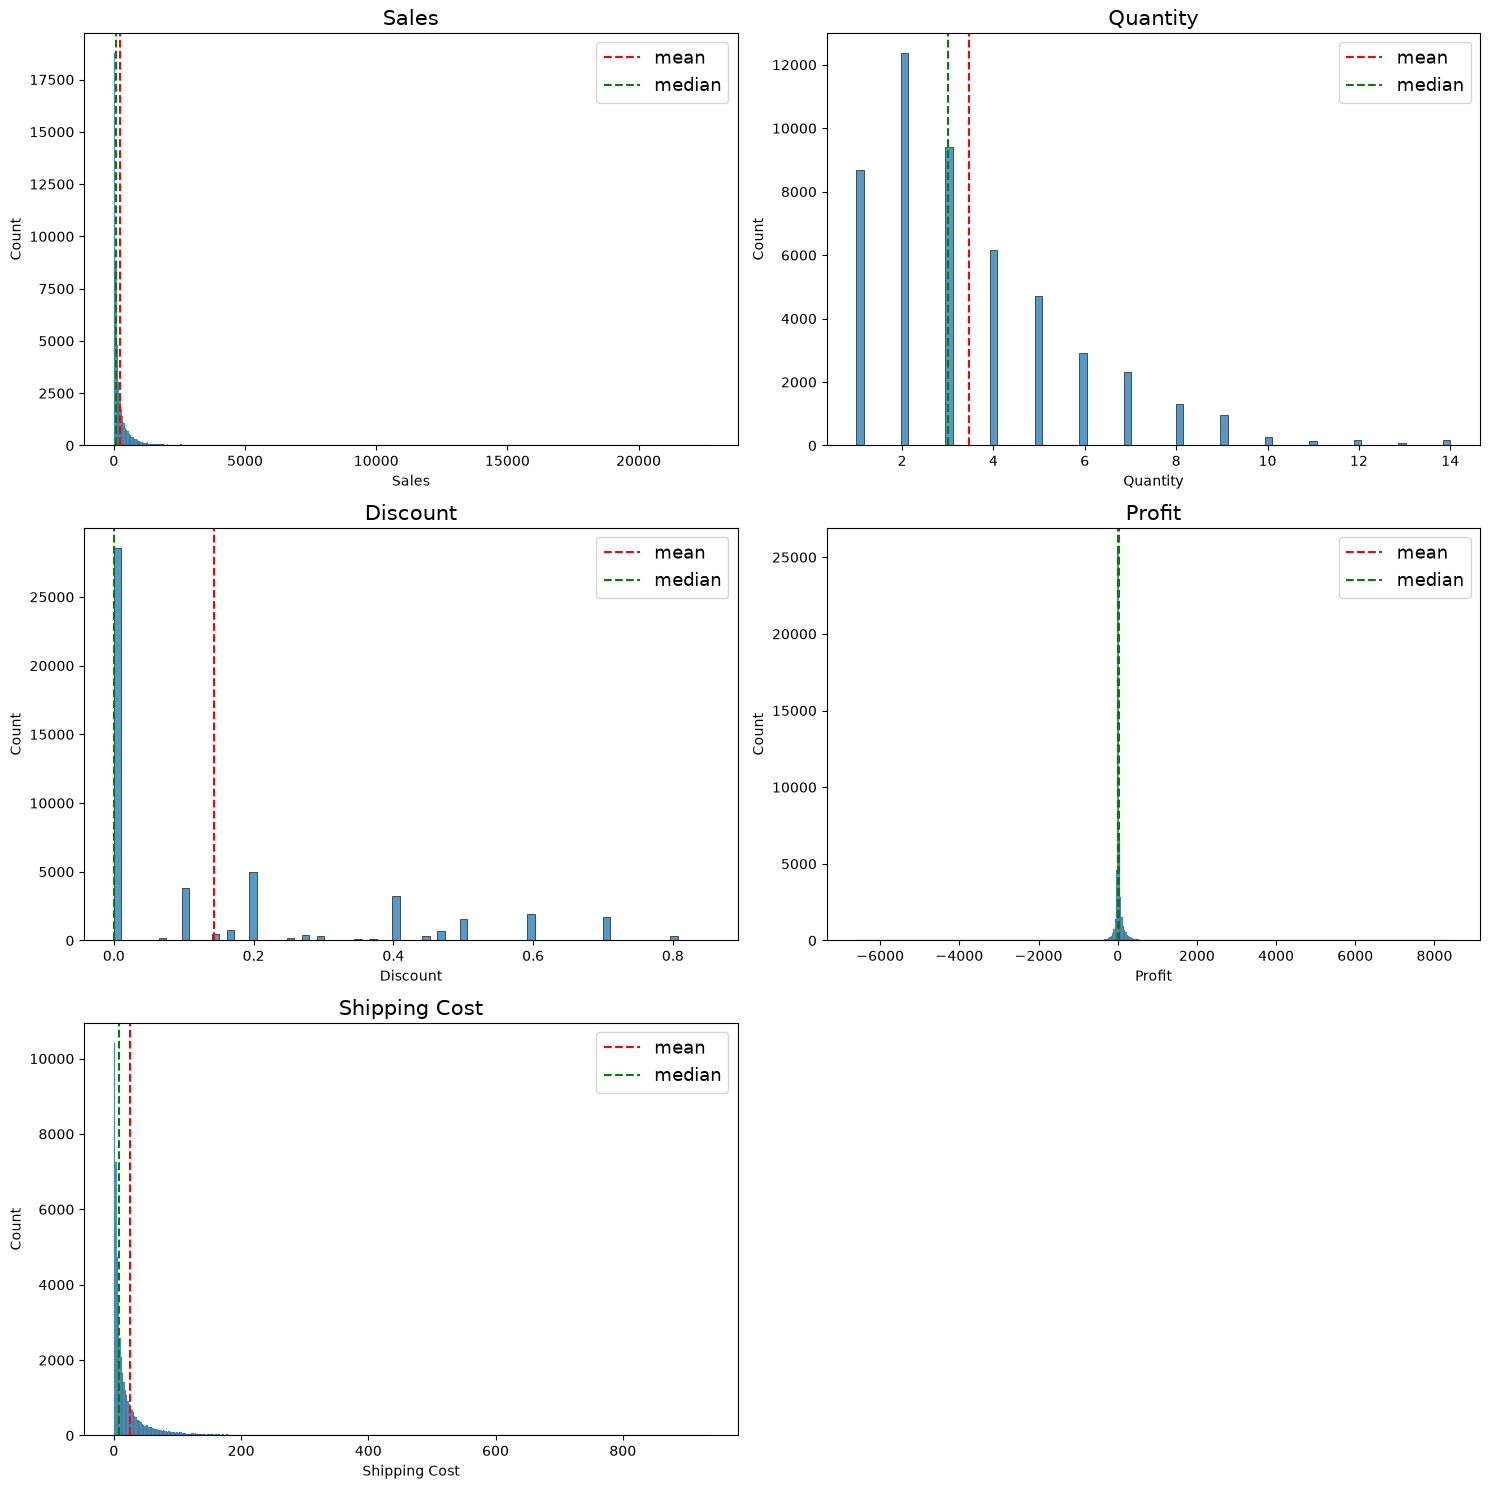

In [48]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for ax, c in zip(axes, numeric_columns):
    sns.histplot(df[c], ax=ax)
    ax.axvline(df[c].mean(), color="red", linestyle="--", label="mean")
    ax.axvline(df[c].median(), color="green", linestyle="--", label="median")
    ax.set_title(c, fontsize=15)
    ax.legend(fontsize=13)
for ax in axes[len(numeric_columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

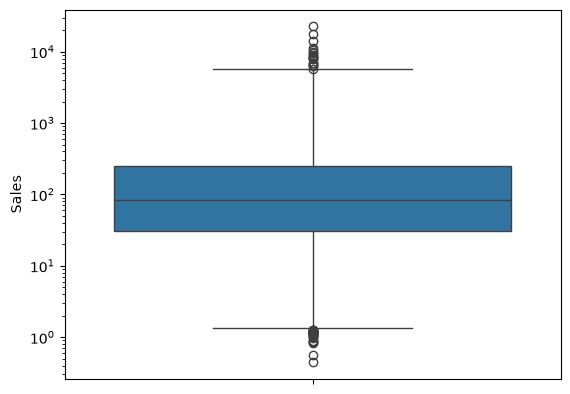

In [49]:
sns.boxplot(df['Sales'] , log_scale=True)
plt.show()

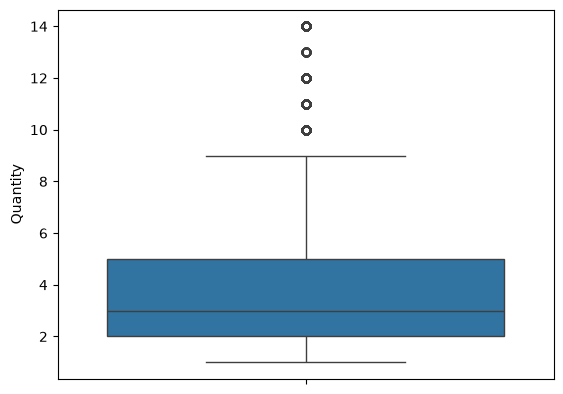

In [50]:
sns.boxplot(df['Quantity'])
plt.show()

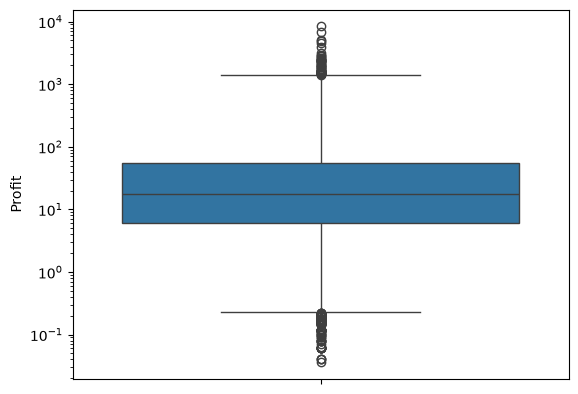

In [51]:
sns.boxplot(df['Profit'] , log_scale=True)
plt.show()

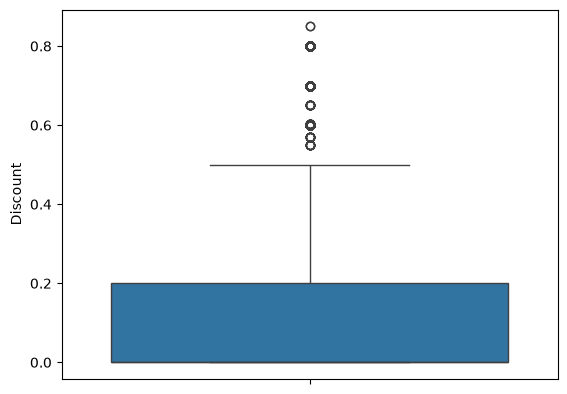

In [52]:
sns.boxplot(df['Discount'])
plt.show()

## Outliers

In [53]:
def outlier_detector(col, method="iqr", k=1.5, z_thresh=3, clip=False) -> pd.Series:
    col = col.replace([np.inf, -np.inf], np.nan)

    if method == "iqr":
        q1, q3 = col.quantile(0.25), col.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        mask = (col < lower) | (col > upper)

        if clip:
            return col.clip(lower, upper)
        return mask

    elif method == "zscore":
        z = col.sub(col.mean()).div(col.std()).abs()
        mask = z > z_thresh

        if clip:
            mean, std = col.mean(), col.std()
            lower = mean - z_thresh * std
            upper = mean + z_thresh * std
            return col.clip(lower, upper)
        return mask

    elif method == "intersection":
        iqr_mask = outlier_detector(col, "iqr", k=k, clip=False)
        z_mask = outlier_detector(col, "zscore", z_thresh=z_thresh, clip=False)
        mask = iqr_mask & z_mask

        if clip:
            q1, q3 = col.quantile(0.25), col.quantile(0.75)
            iqr_val = q3 - q1
            iqr_lower, iqr_upper = q1 - k * iqr_val, q3 + k * iqr_val
            result = col.copy()
            result[mask] = result[mask].clip(iqr_lower, iqr_upper)
            return result
        return mask

In [54]:
for col in numeric_columns:
    print(col, int(outlier_detector(df[col]).sum()) , round((int(outlier_detector(df[col]).sum()) / df[col].shape[0]) * 100 , 2) , '%')

Sales 5466 11.0 %
Quantity 847 1.71 %
Discount 3981 8.01 %
Profit 9448 19.02 %
Shipping Cost 5744 11.56 %


In [55]:
for col in numeric_columns:
    print(col, int(outlier_detector(df[col] , method='zscore').sum()) ,
        round((int(outlier_detector(df[col] , method='zscore').sum()) / df[col].shape[0]) * 100 , 2) , '%')

Sales 996 2.01 %
Quantity 578 1.16 %
Discount 313 0.63 %
Profit 831 1.67 %
Shipping Cost 1007 2.03 %


In [56]:
def corr_heatmap(numeric_df, method="spearman"):
    cor = numeric_df.corr(method=method)
    plt.figure(figsize=(20,10))
    sns.heatmap(cor, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0,
                annot_kws={"size": 15})
    
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    
    plt.title(f"Correlation Heatmap: {method.capitalize()}" , fontsize=18)
    plt.tight_layout()
    plt.show()

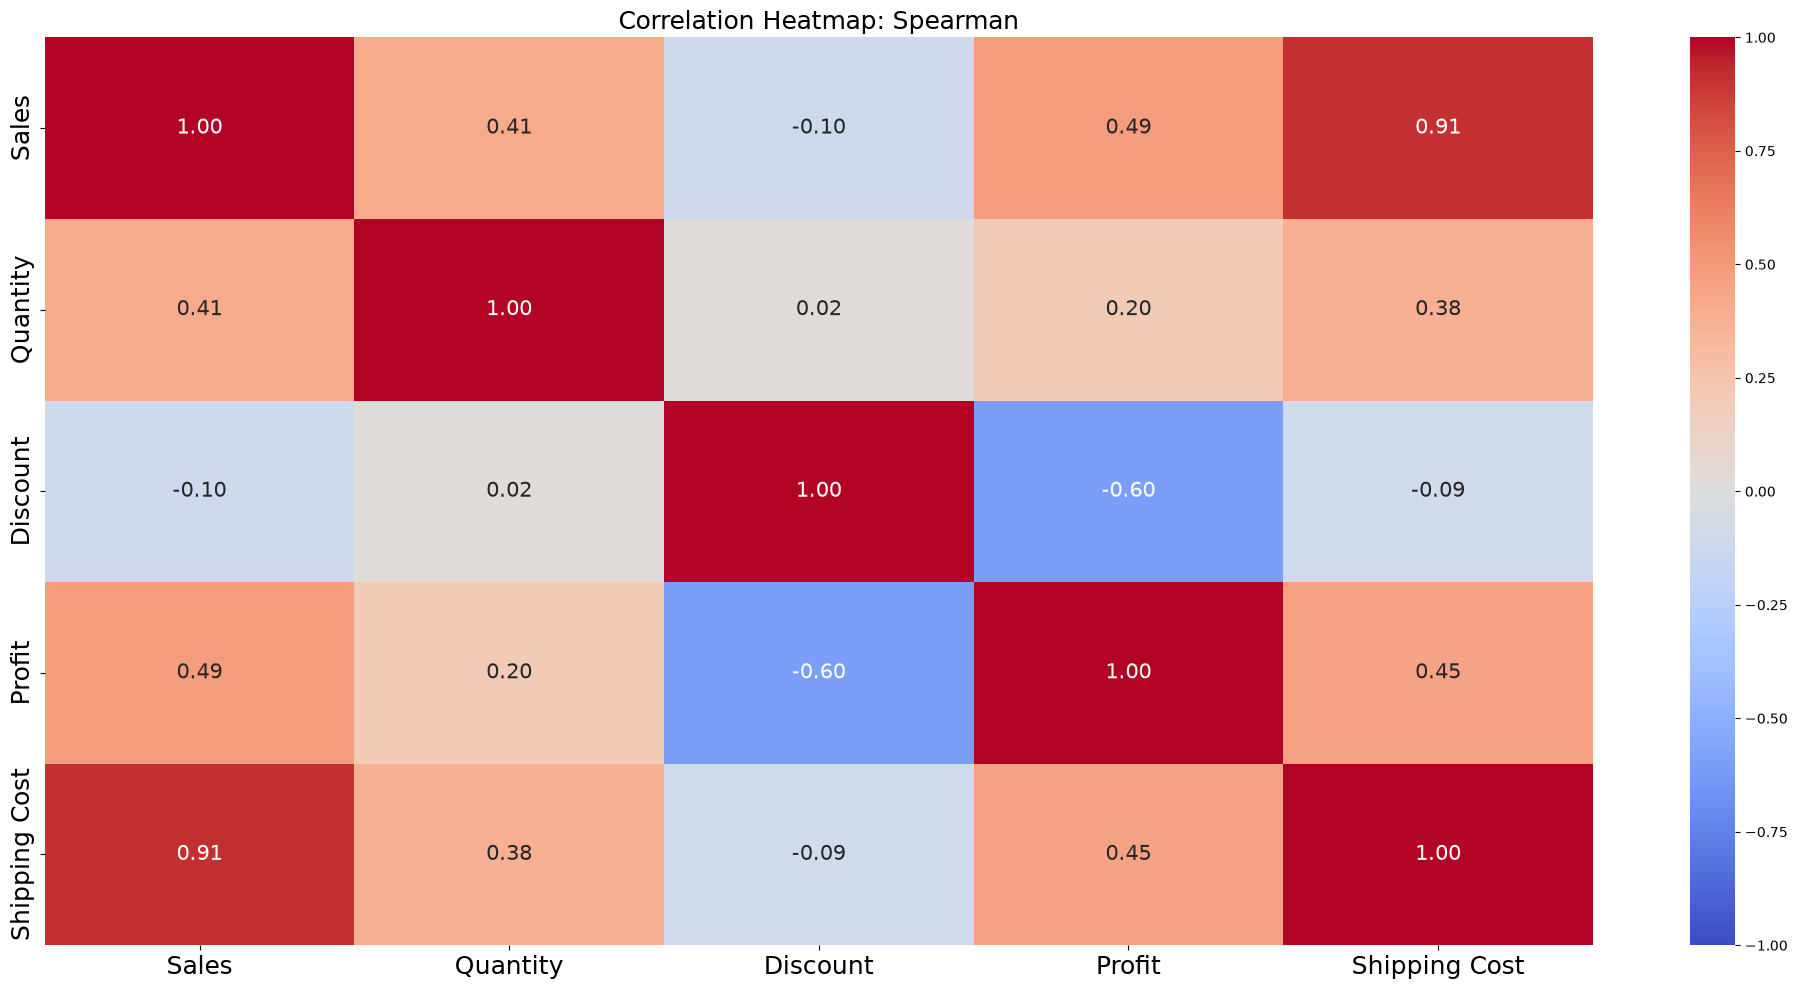

In [57]:
corr_heatmap(df[numeric_columns])

In [58]:
numeric_columns

['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']

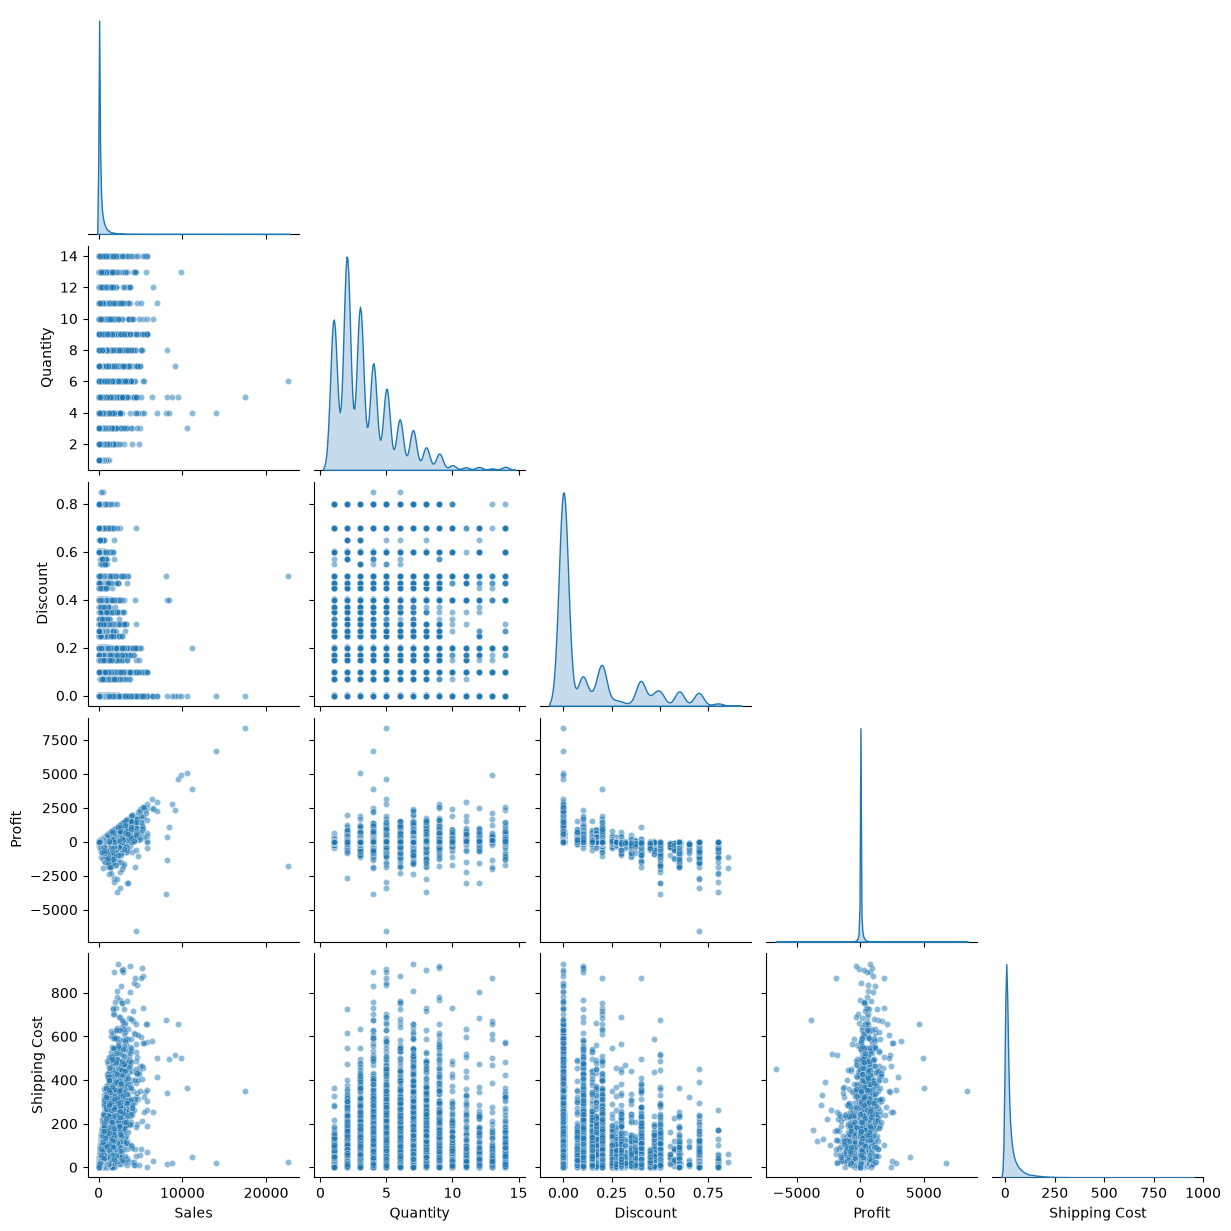

In [59]:
sns.pairplot(df[numeric_columns],diag_kind="kde", corner=True, plot_kws={"alpha": 0.5, "s": 20})

plt.show()

## Statistical Tests

In [60]:
def compare_two_categorical(df, col_1, col_2, alpha=0.05):

    contingency_table = pd.crosstab(df[col_1], df[col_2])
    chi2_stat, p_value, dof, expected_table = chi2_contingency(contingency_table)

    print(f"chi2_stat: {chi2_stat:.4f}")
    print(f"p-value: {p_value:.4g}")

    if p_value < alpha:
        print("Reject the Null Hypothesis")
        print(f"There IS a significant association between '{col_1}' and '{col_2}'.")
    else:
        print("Fail to Reject the Null Hypothesis")
        print(f"There is NO significant association between '{col_1}' and '{col_2}'.")

In [61]:
def numeric_vs_categorical(data, col_1, col_2, alpha=0.05):


    categories = data[col_2].dropna().unique()
    X1 = data.loc[data[col_2] == categories[0], col_1].dropna()
    X2 = data.loc[data[col_2] == categories[1], col_1].dropna()

    normal_p0 = stats.normaltest(X1).pvalue
    normal_p1 = stats.normaltest(X2).pvalue
    print(f"Normal test group '{categories[0]}': p = {normal_p0:.4g}")
    print(f"Normal test group '{categories[1]}': p = {normal_p1:.4g}")

    if normal_p0 > alpha and normal_p1 > alpha:
        t, p = stats.ttest_ind(X1, X2)
        print("Normal distribution -> t-test")
        print(f"t = {t:.4f}, p = {p:.4g}")
    else:
        try:
            X1_bc, _ = stats.boxcox(X1 - X1.min() + 1)
            X2_bc, _ = stats.boxcox(X2 - X2.min() + 1)
            normal_p0_bc = stats.normaltest(X1_bc).pvalue
            normal_p1_bc = stats.normaltest(X2_bc).pvalue

            if normal_p0_bc > alpha and normal_p1_bc > alpha:
                t, p = stats.ttest_ind(X1_bc, X2_bc)
                print("Normal after Box-Cox -> t-test")
                print(f"t = {t:.4f}, p = {p:.4g}")
            else:
                u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
                print("Not normal after Box-Cox -> Mann-Whitney U")
                print(f"U = {u:.1f}, p = {p:.4g}")
        except Exception:
            u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
            print("Box-Cox not applicable -> Mann-Whitney U")
            print(f"U = {u:.1f}, p = {p:.4g}")

    result = "Significant" if p < alpha else "Not Significant"
    print("Result:", result)
    return p


In [62]:
def anova_test_pro(df, group_col, target_col, equal_var=True):
    temp = df[[group_col, target_col]].dropna()

    if temp[group_col].nunique() < 2:
        print("Insufficient Groups")
        return None, None, "Insufficient Groups"

    if equal_var:
        res = anova_oneway(
            data=temp[target_col],
            groups=temp[group_col],
            use_var="equal"
        )
        f_stat = res.statistic
        p = res.pvalue
        test_name = "Classic ANOVA"
    else:
        res = anova_oneway(
            data=temp[target_col],
            groups=temp[group_col],
            use_var="unequal"
        )
        f_stat = res.statistic
        p = res.pvalue
        test_name = "Welch ANOVA"

    result = "Significant" if p < 0.05 else "Not Significant"

    print(f"Test used: {test_name}")
    print(f"F-stat = {f_stat:.4f}")
    print(f"p-value = {p:.4g}")
    print(f"Result: {result}")

    return f_stat, p, result


In [63]:
def levene_test(df, group_col, value_col, center='median'):
    groups = []

    for group in df[group_col].dropna().unique():
        sample = df.loc[df[group_col] == group, value_col].dropna()
        if len(sample) > 0:
            groups.append(sample)

    if len(groups) < 2:
        raise ValueError("Need at least 2 groups with data for Levene test.")

    stat, p = levene(*groups, center=center)
    print(f"P-value is: {p}")

### Returned against Profit

In [64]:
numeric_vs_categorical(df , 'Profit' , 'Returned')

Normal test group '0': p = 0
Normal test group '1': p = 0
Not normal after Box-Cox -> Mann-Whitney U
U = 64445184.0, p = 1.473e-11
Result: Significant


np.float32(1.4732857e-11)

### Profit against Category

In [65]:
levene_test(df , 'Category' , 'Profit')

P-value is: 0.0


In [66]:
anova_test_pro(df , 'Category' , 'Profit' ,equal_var=False)

Test used: Welch ANOVA
F-stat = 163.2780
p-value = 7.414e-71
Result: Significant


(np.float64(163.27795081496774),
 np.float64(7.413535152600924e-71),
 'Significant')

In [67]:
games_howell = pg.pairwise_gameshowell(data=df,dv='Profit',between='Category')
games_howell

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,Furniture,Office Supplies,28.232306,16.464212,11.768093,2.172140,5.417740,11321.038590,1.845400e-07,0.085929
1,Furniture,Technology,28.232306,65.458031,-37.225723,3.428619,-10.857351,18223.844820,1.627365e-12,-0.155552
2,Office Supplies,Technology,16.464212,65.458031,-48.993820,2.792366,-17.545628,10806.433967,7.321366e-12,-0.301358


### Profit against Market

In [68]:
levene_test(df , 'Market' , 'Profit')

P-value is: 1.8768267956370035e-28


In [69]:
anova_test_pro(df , 'Market' , 'Profit' ,equal_var=False)

Test used: Welch ANOVA
F-stat = 29.7096
p-value = 3.516e-35
Result: Significant


(np.float64(29.709600743812), np.float64(3.516286412800185e-35), 'Significant')

In [70]:
games_howell = pg.pairwise_gameshowell(data=df,dv='Profit',between='Market')
games_howell[games_howell['pval'] < 0.05].sort_values('diff' , ascending = False)

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
11,Canada,EMEA,46.947926,10.582015,36.365910,6.355446,5.722007,467.837195,3.930222e-07,0.256848
2,APAC,EMEA,39.629162,10.582015,29.047146,2.625125,11.065052,10870.533935,1.020739e-12,0.178524
13,Canada,LATAM,46.947926,21.955399,24.992527,6.125238,4.080254,404.058870,1.057748e-03,0.210830
0,APAC,Africa,39.629162,20.432905,19.196257,2.735233,7.018143,9497.000541,4.783618e-11,0.117020
4,APAC,LATAM,39.629162,21.955399,17.673763,2.004527,8.816925,19693.292046,0.000000e+00,0.119573
18,EU,LATAM,34.331470,21.955399,12.376072,2.172565,5.696527,15338.319840,2.605372e-07,0.084941
5,APAC,US,39.629162,28.831310,10.797852,2.859366,3.776309,18004.588291,3.036134e-03,0.053062
7,Africa,EMEA,20.432905,10.582015,9.850890,3.014469,3.267870,9182.477515,1.873734e-02,0.067935
16,EMEA,LATAM,10.582015,21.955399,-11.373384,2.371423,-4.796015,8070.473782,3.390785e-05,-0.089505
8,Africa,EU,20.432905,34.331470,-13.898565,2.860666,-4.858507,10261.139922,2.475474e-05,-0.084816


### Sales against Segment

In [71]:
levene_test(df , 'Segment' , 'Sales')

P-value is: 0.9273583889007568


In [72]:
anova_test_pro(df , 'Segment' , 'Sales' ,equal_var=True)

Test used: Classic ANOVA
F-stat = 0.0736
p-value = 0.929
Result: Not Significant


(np.float64(0.07360197451253787),
 np.float64(0.9290415037484362),
 'Not Significant')

### Shipping Cost against Ship Mode

In [73]:
levene_test(df , 'Ship Mode' , 'Shipping Cost')

P-value is: 0.0


In [74]:
anova_test_pro(df , 'Ship Mode' , 'Shipping Cost' ,equal_var=False)

Test used: Welch ANOVA
F-stat = 256.8061
p-value = 1.043e-159
Result: Significant


(np.float64(256.8060539730035),
 np.float64(1.042665067564094e-159),
 'Significant')

In [75]:
games_howell = pg.pairwise_gameshowell(data=df,dv='Shipping Cost',between='Ship Mode')
games_howell.sort_values('diff' , ascending = False)

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
4,Same Day,Standard Class,42.010181,19.790215,22.219967,1.676922,13.250448,2727.511016,0.000000e+00,0.480965
2,First Class,Standard Class,40.436230,19.790215,20.646015,0.968948,21.307652,8179.588802,1.290967e-12,0.404642
3,Same Day,Second Class,42.010181,30.114565,11.895617,1.781873,6.675906,3456.222458,1.701561e-10,0.171415
5,Second Class,Standard Class,30.114565,19.790215,10.324350,0.690012,14.962561,12762.849796,5.038636e-12,0.214667
1,First Class,Second Class,40.436230,30.114565,10.321665,1.140993,9.046210,13525.236193,0.000000e+00,0.144422
0,First Class,Same Day,40.436230,42.010181,-1.573952,1.907306,-0.825222,4401.267986,8.425425e-01,-0.019367


### Returned against Category

In [76]:
compare_two_categorical(df , 'Returned' , 'Category')

chi2_stat: 9.4753
p-value: 0.008759
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Category'.


### Returned against Discount

In [77]:
df["Has_Discount"] = np.where(df["Discount"] > 0, "Discounted", "No Discount")
df["Has_Discount"] = df["Has_Discount"].astype("category")

In [78]:
compare_two_categorical(df , 'Returned' , 'Has_Discount')

chi2_stat: 9.1686
p-value: 0.002462
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Has_Discount'.


### Returned against Ship Mode

In [79]:
compare_two_categorical(df , 'Returned' , 'Ship Mode')

chi2_stat: 9.0121
p-value: 0.02913
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Ship Mode'.


### Returned against Segment

In [80]:
compare_two_categorical(df , 'Returned' , 'Segment')

chi2_stat: 10.5282
p-value: 0.005174
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Segment'.


### Returned against Segment

In [81]:
compare_two_categorical(df , 'Returned' , 'Market')

chi2_stat: 792.1468
p-value: 7.66e-168
Reject the Null Hypothesis
There IS a significant association between 'Returned' and 'Market'.


### Market against Category

In [82]:
compare_two_categorical(df , 'Category' , 'Market')

chi2_stat: 558.2167
p-value: 8.755e-112
Reject the Null Hypothesis
There IS a significant association between 'Category' and 'Market'.


# Machine Learning

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13576\996841475.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


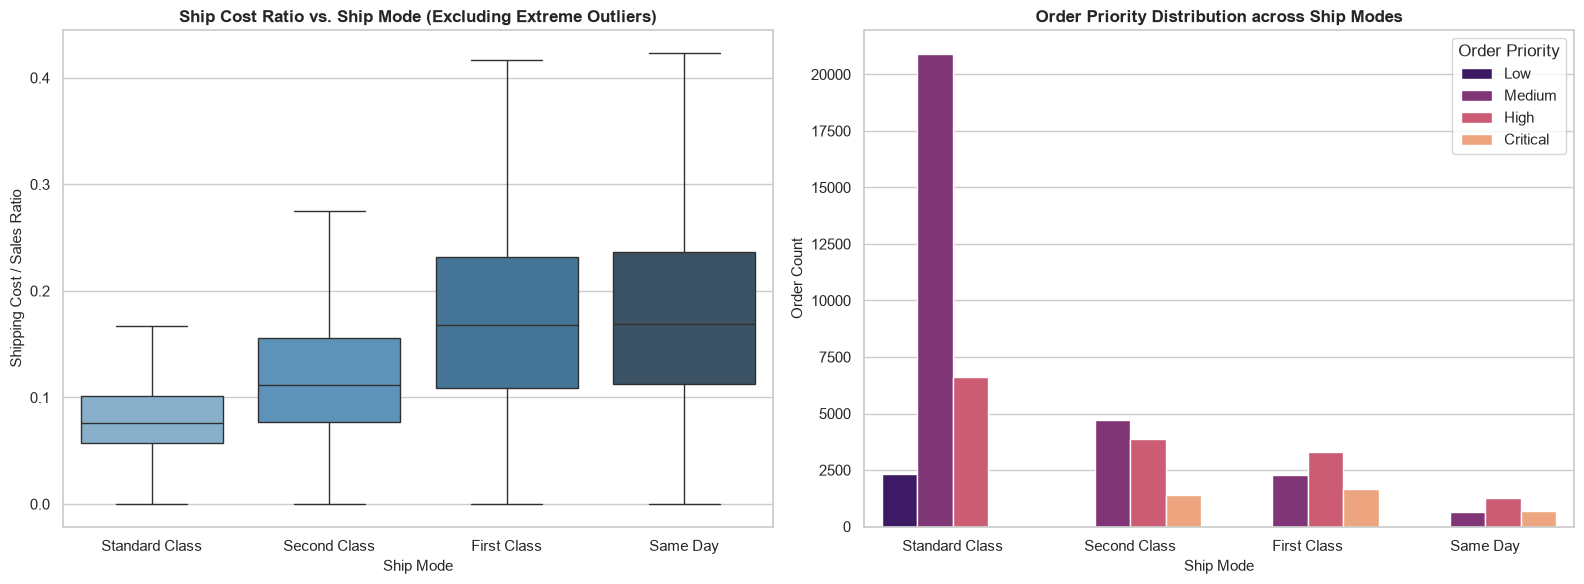

In [83]:
if "Ship_Cost_Ratio" not in df.columns:

    df["Ship_Cost_Ratio"] = df["Shipping Cost"] / df["Sales"].replace(0, np.nan)

# تنظیم استایل بصری تمیز و خوانا
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


ship_mode_order = ["Standard Class", "Second Class", "First Class", "Same Day"]

sns.boxplot(
    data=df,
    x="Ship Mode",
    y="Ship_Cost_Ratio",
    order=ship_mode_order,
    palette="Blues_d",
    showfliers=False,  # حذف نقاط پرت اغراق‌آمیز برای وضوح میانه و چارک‌ها
    ax=axes[0],
)

axes[0].set_title(
    "Ship Cost Ratio vs. Ship Mode (Excluding Extreme Outliers)",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xlabel("Ship Mode", fontsize=11)
axes[0].set_ylabel("Shipping Cost / Sales Ratio", fontsize=11)


priority_order = ["Low", "Medium", "High", "Critical"]


sns.countplot(
    data=df,
    x="Ship Mode",
    hue="Order Priority",
    order=ship_mode_order,
    hue_order=priority_order,
    palette="magma",
    ax=axes[1],
)

axes[1].set_title(
    "Order Priority Distribution across Ship Modes",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Ship Mode", fontsize=11)
axes[1].set_ylabel("Order Count", fontsize=11)
axes[1].legend(title="Order Priority", loc="upper right")

plt.tight_layout()
plt.show()
df.drop(columns='Ship_Cost_Ratio' , inplace=True)

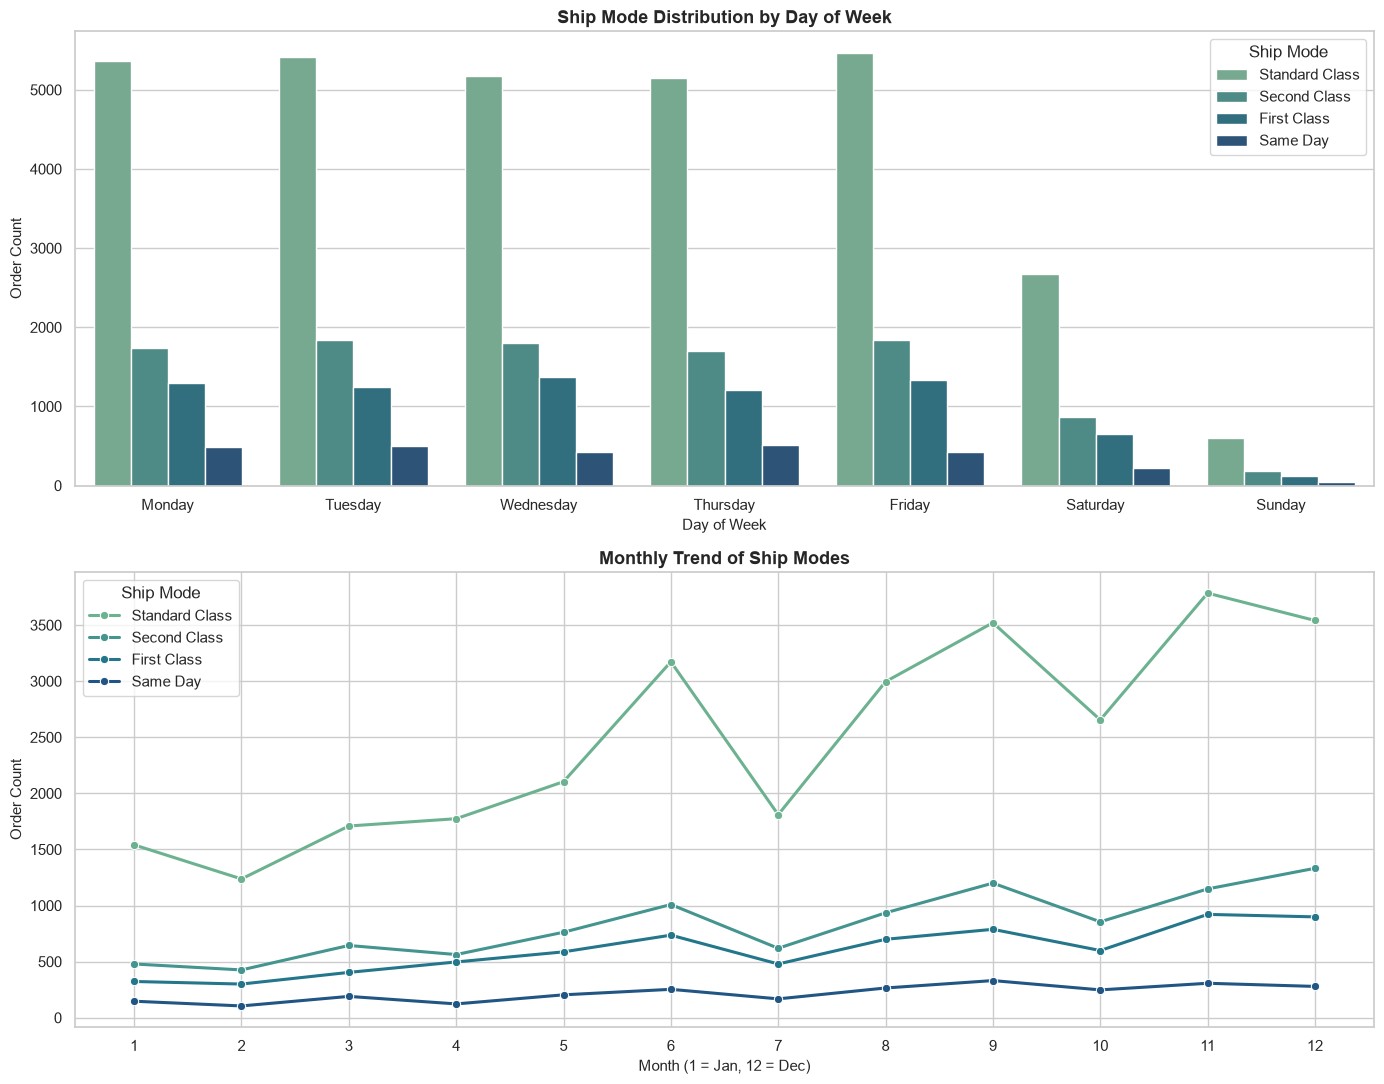

In [84]:
if not pd.api.types.is_datetime64_any_dtype(df["Order Date"]):
    df["Order Date"] = pd.to_datetime(df["Order Date"])


df["Order_DayName"] = df["Order Date"].dt.day_name()
df["Order_Month"] = df["Order Date"].dt.month

days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
ship_mode_order = ["Standard Class", "Second Class", "First Class", "Same Day"]


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 11))


sns.countplot(
    data=df,
    x="Order_DayName",
    hue="Ship Mode",
    order=days_order,
    hue_order=ship_mode_order,
    palette="crest",
    ax=axes[0],
)

axes[0].set_title(
    "Ship Mode Distribution by Day of Week", fontsize=13, fontweight="bold"
)
axes[0].set_xlabel("Day of Week", fontsize=11)
axes[0].set_ylabel("Order Count", fontsize=11)
axes[0].legend(title="Ship Mode", loc="upper right")


monthly_ship = (
    df.groupby(["Order_Month", "Ship Mode"], observed=False)
    .size()
    .reset_index(name="Count")
)

sns.lineplot(
    data=monthly_ship,
    x="Order_Month",
    y="Count",
    hue="Ship Mode",
    hue_order=ship_mode_order,
    marker="o",
    palette="crest",
    linewidth=2.2,
    ax=axes[1],
)

axes[1].set_title("Monthly Trend of Ship Modes", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Month (1 = Jan, 12 = Dec)", fontsize=11)
axes[1].set_ylabel("Order Count", fontsize=11)
axes[1].set_xticks(range(1, 13))
axes[1].legend(title="Ship Mode", loc="upper left")

plt.tight_layout()
plt.show()
df.drop(columns=['Order_DayName' , 'Order_Month'] , inplace=True)

In [85]:
#df['Order_Quarter'] = df['Order Date'].dt.quarter
df["Order_Month"] = df["Order Date"].dt.month
df["Order_DayOfWeek"] = df["Order Date"].dt.dayofweek
df['Is_Weekend'] = df['Order Date'].dt.dayofweek.isin([5, 6]).astype('int8')

In [86]:
days_until_month_end = (df["Order Date"].dt.days_in_month- df["Order Date"].dt.day)
is_quarter_end_month = df["Order Date"].dt.month.isin([3, 6, 9, 12])
df["Is_Month_End"] = (days_until_month_end < 3).astype("int8")
df["Is_Quarter_End"] = is_quarter_end_month& (days_until_month_end < 3).astype("int8")

In [87]:
df["Profit_Margin"] = df["Profit"] / (df["Sales"])
df['Price_Per_Unit'] = df['Sales'] / (df['Quantity'])
df['Discount_Impact'] = df['Sales'] * df['Discount']

In [88]:
#df['Ship_Cost_Ratio'] = df['Shipping Cost'] / df['Sales']

In [89]:
df["Order Priority"] = df["Order Priority"].map({"Low": 0, "Medium": 1, "High": 2, "Critical": 3}).astype('int8')

In [90]:
"""customer_freq = df["Customer ID"].value_counts().to_dict()
df["Customer_Order_Count"] = df["Customer ID"].map(customer_freq).astype("int16")"""

'customer_freq = df["Customer ID"].value_counts().to_dict()\ndf["Customer_Order_Count"] = df["Customer ID"].map(customer_freq).astype("int16")'

In [91]:
#df['Customer_Avg_Sales'] = df.groupby('Customer ID')['Sales'].transform('mean')

In [92]:
"""city_freq = df["City"].value_counts(normalize=True).to_dict()
df["City_Freq"] = df["City"].map(city_freq).astype("float32")

state_freq = df["State"].value_counts(normalize=True).to_dict()
df["State_Freq"] = df["State"].map(state_freq).astype("float32")"""

'city_freq = df["City"].value_counts(normalize=True).to_dict()\ndf["City_Freq"] = df["City"].map(city_freq).astype("float32")\n\nstate_freq = df["State"].value_counts(normalize=True).to_dict()\ndf["State_Freq"] = df["State"].map(state_freq).astype("float32")'

In [93]:
df["Ship Mode"].value_counts()

Ship Mode
Standard Class    29846
Second Class       9972
First Class        7232
Same Day           2620
Name: count, dtype: int64

In [94]:
drop_cols = [
    "Order ID",
    "Product ID",
#    "Customer ID",
    "Customer Name",
    "Product Name",
    "Shipping ID",
    "Ship Date",
    "Shipping Cost",
#    "Order Date",
#    "City",
#    "State",
    "Returned",
]

In [95]:
df_cleaned = df.drop(columns=drop_cols)

In [96]:
X = df_cleaned.drop(columns=["Ship Mode"])
y = df_cleaned["Ship Mode"]

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [98]:
X_train = X_train.copy()
X_test = X_test.copy()

customer_freq = X_train["Customer ID"].value_counts().to_dict()
X_train["Customer_Order_Count"] = X_train["Customer ID"].map(customer_freq).fillna(0).astype("int16")
X_test["Customer_Order_Count"] = X_test["Customer ID"].map(customer_freq).fillna(0).astype("int16")


customer_avg_sales = X_train.groupby('Customer ID')['Sales'].mean().to_dict()
X_train['Customer_Avg_Sales'] = X_train['Customer ID'].map(customer_avg_sales).fillna(0).astype("float32")
X_test['Customer_Avg_Sales'] = X_test['Customer ID'].map(customer_avg_sales).fillna(0).astype("float32")



city_freq = X_train["City"].value_counts(normalize=True).to_dict()
X_train["City_Freq"] = X_train["City"].map(city_freq).fillna(0).astype("float32")
X_test["City_Freq"] = X_test["City"].map(city_freq).fillna(0).astype("float32")


state_freq = X_train["State"].value_counts(normalize=True).to_dict()
X_train["State_Freq"] = X_train["State"].map(state_freq).fillna(0).astype("float32")
X_test["State_Freq"] = X_test["State"].map(state_freq).fillna(0).astype("float32")

X_train = X_train.drop(columns=["City", "State"])
X_test = X_test.drop(columns=["City", "State"])

train_sort_idx = X_train.sort_values(by=['Customer ID', 'Order Date']).index
X_train_sorted = X_train.loc[train_sort_idx]

y_train_dummies = pd.get_dummies(y_train.loc[train_sort_idx], prefix='Prior_Ship', dtype=int)
ship_cols = y_train_dummies.columns.tolist()

for col in ship_cols:
    feat_name = f'Customer_{col}_Count'
    X_train.loc[train_sort_idx, feat_name] = (
        y_train_dummies[col].groupby(X_train_sorted['Customer ID'])
                            .transform(lambda s: s.shift(1).fillna(0).cumsum())
    )

customer_ship_history = (
    y_train_dummies.assign(CustomerID=X_train_sorted['Customer ID'])
                   .groupby('CustomerID')
                   .sum()
)

for col in ship_cols:
    feat_name = f'Customer_{col}_Count'
    X_test[feat_name] = X_test['Customer ID'].map(customer_ship_history[col]).fillna(0)

new_feature_cols = [f'Customer_{col}_Count' for col in ship_cols]

for col in new_feature_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce').fillna(0).astype('int16')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce').fillna(0).astype('int16')


In [99]:
X_train = X_train.drop(columns=['Customer ID' , 'Order Date'])
X_test = X_test.drop(columns=['Customer ID' , 'Order Date'])

In [100]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

In [101]:
preprocessor = ColumnTransformer([
    ("num", RobustScaler(), numeric_cols),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        categorical_cols
    )
])

In [102]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        C=0.1,
        random_state=42
    ),

    "Balanced Random Forest": BalancedRandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),

    "Balanced Bagging": BalancedBaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=15,
            random_state=42
        ),
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200,
        early_stopping=True,
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        decision_function_shape="ovr",
        cache_size=2000,
        random_state=42
    )
}



In [103]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro F1": f1_score(
            y_test,
            predictions,
            average="macro"
        ),
        "Weighted F1": f1_score(
            y_test,
            predictions,
            average="weighted"
        )
    })



results_df = pd.DataFrame(results)

print(
    results_df.sort_values(
        by="Macro F1",
        ascending=False
    )
)

                    Model  Accuracy  Macro F1  Weighted F1
2        Balanced Bagging  0.598047  0.440577     0.595386
3    HistGradientBoosting  0.661667  0.428521     0.607956
1  Balanced Random Forest  0.584659  0.411133     0.574621
4                     SVM  0.572378  0.394772     0.567160
0     Logistic Regression  0.536038  0.392487     0.552241


The difference between **HistGradientBoosting** and other models is significant,so we apply a gridsearch to find the best hyperparameters for this model.

In [104]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", HistGradientBoostingClassifier(
        max_iter=200,
        early_stopping=True,
        random_state=42
    ))
])

In [105]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [106]:
perm_importance = permutation_importance(
    pipeline, 
    X_test, 
    y_test, 
    scoring="f1_macro", 
    n_repeats=10, 
    random_state=42
)


feature_names = X_test.columns
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Mean": perm_importance.importances_mean,
    "Importance_Std": perm_importance.importances_std
}).sort_values(by="Importance_Mean", ascending=False)

print(importance_df)


                                     Feature  Importance_Mean  Importance_Std
4                             Order Priority         0.133439        0.003437
21                        Customer_Avg_Sales         0.047630        0.002578
23                                State_Freq         0.040553        0.003838
22                                 City_Freq         0.039933        0.002960
20                      Customer_Order_Count         0.038548        0.002184
9                                    Country         0.033394        0.002195
12                               Order_Month         0.028962        0.001950
25        Customer_Prior_Ship_Same Day_Count         0.025821        0.003684
24     Customer_Prior_Ship_First Class_Count         0.024440        0.003662
26    Customer_Prior_Ship_Second Class_Count         0.023478        0.004591
27  Customer_Prior_Ship_Standard Class_Count         0.021943        0.004753
13                           Order_DayOfWeek         0.021620   

we delete the ones that have importance mean of less than or equal to zero and the ones whose Importance_Std is larger than Importance_Mean

In [107]:
drop_features = [
    "Quantity",        
    "Is_Weekend",       
    "Is_Quarter_End",   
    "Category",         
    "Has_Discount",      
    "Sub-Category",    
    "Discount",          
    "Discount_Impact",   
    "Profit",           
    "Is_Month_End" ]

In [108]:
X_train_clean = X_train.drop(columns=drop_features)
X_test_clean = X_test.drop(columns=drop_features)

In [109]:
numeric_cols = [col for col in numeric_cols if col not in drop_features]
categorical_cols =[col for col in categorical_cols if col not in drop_features]

In [110]:
numeric_cols

['Sales',
 'Order Priority',
 'Order_Month',
 'Order_DayOfWeek',
 'Profit_Margin',
 'Price_Per_Unit',
 'Customer_Order_Count',
 'Customer_Avg_Sales',
 'City_Freq',
 'State_Freq',
 'Customer_Prior_Ship_First Class_Count',
 'Customer_Prior_Ship_Same Day_Count',
 'Customer_Prior_Ship_Second Class_Count',
 'Customer_Prior_Ship_Standard Class_Count']

In [111]:
categorical_cols

['Market', 'Segment', 'Country', 'Region']

In [112]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OrdinalEncoder(
            handle_unknown="use_encoded_value", 
            unknown_value=-1
        ), categorical_cols)
    ]
)

In [113]:
categorical_mask = [False] * len(numeric_cols) + [True] * len(categorical_cols)

In [114]:
sample_weights_train = compute_sample_weight("balanced", y_train)

In [115]:
models_config = {
    "Hist Gradient Boosting": {
        "model": Pipeline([
            ("preprocessor", preprocessor),
            ("model", HistGradientBoostingClassifier(
                categorical_features=categorical_mask,
                max_iter=400,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=15,
                random_state=42
            ))
        ]),
        "params": {
            "model__learning_rate": [0.01, 0.05, 0.1, 1.0],
            "model__max_depth": [3, 4, 5],
            "model__max_leaf_nodes": [5 , 10 , 15],
            "model__min_samples_leaf": [30 , 50 , 70],
            "model__l2_regularization": [0.0, 0.01, 0.1],
            "model__max_features": [0.3, 0.5, 0.8, 1.0]
        }
    }
}

In [116]:
results = []
best_models = {}

for name, config in models_config.items():
    print(f"Running GridSearch for: {name} ...")

    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=3,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(
        X_train_clean,
        y_train,
        model__sample_weight=sample_weights_train
    )

    best_model = grid.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test_clean)

    results.append({
        "Classifier": name,
        "Best CV F1 (Macro)": round(grid.best_score_, 4),
        "Test F1 (Macro)": round(
            f1_score(y_test, y_pred, average="macro"),
            4
        ),
        "Best Hyperparameters": grid.best_params_
    })

results_df = pd.DataFrame(results)


Running GridSearch for: Hist Gradient Boosting ...
Fitting 3 folds for each of 1296 candidates, totalling 3888 fits


In [117]:
results_df

,Classifier,Best CV F1 (Macro),Test F1 (Macro),Best Hyperparameters
0,Hist Gradient Boosting,0.4943,0.4738,"{'model__l2_regularization': 0.01, 'model__lea..."


In [118]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    

    df_metrics = pd.DataFrame({
        "Train": [
            f1_score(y_train, y_train_pred, average="macro"),
            f1_score(y_train, y_train_pred, average="weighted"),
            accuracy_score(y_train, y_train_pred)
        ],
        "Test": [
            f1_score(y_test, y_test_pred, average="macro"),
            f1_score(y_test, y_test_pred, average="weighted"),
            accuracy_score(y_test, y_test_pred)
        ]
    }, index=["F1 Macro", "F1 Weighted", "Accuracy"])
    

    df_report = pd.DataFrame(classification_report(y_test, y_test_pred, output_dict=True)).T
    

    df_cm = pd.DataFrame(confusion_matrix(y_test, y_test_pred))
    
    return df_metrics, df_report, df_cm

In [119]:
df_metrics, df_report, df_cm = evaluate_model(best_model , X_train_clean , y_train , X_test_clean , y_test)

In [120]:
df_metrics

,Train,Test
F1 Macro,0.737015,0.473832
F1 Weighted,0.785258,0.605160
Accuracy,0.780199,0.597242


The model is terribly **overfitted** so we manually try to regularize it.

In [121]:
df_report

,precision,recall,f1-score,support
First Class,0.351392,0.488935,0.408907,1446.000000
Same Day,0.341682,0.364504,0.352724,524.000000
Second Class,0.399248,0.372431,0.385373,1995.000000
Standard Class,0.780080,0.719048,0.748322,5969.000000
accuracy,0.597242,0.597242,0.597242,0.597242
macro avg,0.468100,0.486230,0.473832,9934.000000
weighted avg,0.618074,0.597242,0.605160,9934.000000


In [122]:
df_cm

,0,1,2,3
0,707,97,259,383
1,136,191,92,105
2,427,103,743,722
3,742,168,767,4292


In [123]:
best_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [124]:
less_overfit_hgbt = clone(best_models["Hist Gradient Boosting"])

In [125]:
less_overfit_hgbt.set_params(
    model__categorical_features=categorical_mask,
    model__learning_rate=0.07,
    model__max_depth=4,
    model__max_leaf_nodes=10,
    model__min_samples_leaf=60,
    model__l2_regularization=0.1,
    model__n_iter_no_change=10
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [126]:
less_overfit_hgbt.fit(X_train_clean,y_train,model__sample_weight=sample_weights_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [127]:
evaluate_model(less_overfit_hgbt , X_train_clean , y_train , X_test_clean , y_test)

(                Train      Test
 F1 Macro     0.598680  0.439539
 F1 Weighted  0.684319  0.575615
 Accuracy     0.673319  0.560902,
                 precision    recall  f1-score      support
 First Class      0.315574  0.479253  0.380560  1446.000000
 Same Day         0.250000  0.431298  0.316527   524.000000
 Second Class     0.366231  0.308772  0.335056  1995.000000
 Standard Class   0.783579  0.676328  0.726014  5969.000000
 accuracy         0.560902  0.560902  0.560902     0.560902
 macro avg        0.428846  0.473913  0.439539  9934.000000
 weighted avg     0.603496  0.560902  0.575615  9934.000000,
      0    1    2     3
 0  693  208  214   331
 1  121  226   81    96
 2  498  193  616   688
 3  884  277  771  4037)

In [128]:
perm_importance = permutation_importance(
    less_overfit_hgbt, 
    X_test_clean, 
    y_test, 
    scoring="f1_macro", 
    n_repeats=10, 
    random_state=42
)


feature_names = X_test_clean.columns
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Mean": perm_importance.importances_mean,
    "Importance_Std": perm_importance.importances_std
}).sort_values(by="Importance_Mean", ascending=False)

print(importance_df)

                                     Feature  Importance_Mean  Importance_Std
1                             Order Priority         0.118291        0.002846
4                                    Country         0.058997        0.003994
11                        Customer_Avg_Sales         0.019358        0.002679
10                      Customer_Order_Count         0.019058        0.003010
6                                Order_Month         0.017590        0.001855
12                                 City_Freq         0.014947        0.002656
13                                State_Freq         0.014877        0.001369
15        Customer_Prior_Ship_Same Day_Count         0.012744        0.001792
16    Customer_Prior_Ship_Second Class_Count         0.010342        0.003685
14     Customer_Prior_Ship_First Class_Count         0.009161        0.001349
7                            Order_DayOfWeek         0.007202        0.001430
17  Customer_Prior_Ship_Standard Class_Count         0.006966   

In [129]:
cols_to_drop_now = [
    "Profit_Margin",   
    "Price_Per_Unit",  
    "Sales",           
    "Market",          
]

In [130]:
X_train_clean = X_train_clean.drop(columns=cols_to_drop_now, errors="ignore")
X_test_clean = X_test_clean.drop(columns=cols_to_drop_now, errors="ignore")

In [131]:
remaining_cols = X_train_clean.columns.tolist()
numeric_cols = [c for c in numeric_cols if c in remaining_cols]
categorical_cols = [c for c in categorical_cols if c in remaining_cols]

---

## Smote

In [145]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            dtype=np.int8
        ), categorical_cols)
    ],
    remainder="drop"
)

cat_indices = list(range(len(numeric_cols), len(numeric_cols) + len(categorical_cols)))


classifier_model = clone(less_overfit_hgbt.steps[-1][1])

classifier_model.set_params(categorical_features=cat_indices)

smote_rf_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smotenc", SMOTENC(
        categorical_features=cat_mask,
        sampling_strategy=custom_strategy,
        k_neighbors=5,
        random_state=42
    )),
    ("classifier", classifier_model
    )
])


smote_rf_pipeline.fit(X_train_clean, y_train)


,steps,"[('preprocessor', ...), ('smotenc', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [146]:
evaluate_model(smote_rf_pipeline , X_train_clean , y_train , X_test_clean , y_test )

(                Train      Test
 F1 Macro     0.585285  0.436402
 F1 Weighted  0.697357  0.609573
 Accuracy     0.733114  0.663580,
                 precision    recall  f1-score     support
 First Class      0.496659  0.308437  0.380546  1446.00000
 Same Day         0.592593  0.183206  0.279883   524.00000
 Second Class     0.516734  0.193484  0.281546  1995.00000
 Standard Class   0.696936  0.948903  0.803632  5969.00000
 accuracy         0.663580  0.663580  0.663580     0.66358
 macro avg        0.575730  0.408507  0.436402  9934.00000
 weighted avg     0.626091  0.663580  0.609573  9934.00000,
      0   1    2     3
 0  446  34  152   814
 1   88  96   66   274
 2  221  13  386  1375
 3  143  19  143  5664)

In [149]:
numeric_cols = [c for c in numeric_cols if c in X_train_clean.columns]
categorical_cols = [c for c in categorical_cols if c in X_train_clean.columns]

preprocessor_step = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OrdinalEncoder(
            handle_unknown="use_encoded_value", 
            unknown_value=-1, 
            dtype=np.int8
        ), categorical_cols)
    ],
    remainder="drop"
)

cat_mask = [False] * len(numeric_cols) + [True] * len(categorical_cols)

grid_pipeline = ImbPipeline([
    ("preprocessor", preprocessor_step),
    ("smotenc", SMOTENC(
        categorical_features=cat_mask,
        random_state=42
    )),
    ("classifier", classifier_model)
])


In [150]:
class_counts = pd.Series(y_train).value_counts()
majority_count = class_counts.max()

sampling_strategies = []
for ratio in [0.25,0.30, 0.35, 0.40]:
    target_count = int(majority_count * ratio)
    strategy = {
        cls: target_count
        for cls, count in class_counts.items()
        if count < target_count
    }
    sampling_strategies.append(strategy)





grid_pipeline = ImbPipeline([
    ("preprocessor", preprocessor_step),
    ("smotenc", SMOTENC(
        categorical_features=cat_mask,
        random_state=42
    )),
    ("classifier", classifier_model)
])


param_grid = {
    "smotenc__sampling_strategy": sampling_strategies,
    "smotenc__k_neighbors": [3, 4 ,5 ,7]
}


cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_smotenc = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True,
    error_score="raise"
)

grid_smotenc.fit(X_train_clean, y_train)


print(f"Best Params: {grid_smotenc.best_params_}")
print(f"Best CV Macro-F1: {grid_smotenc.best_score_:.4f}")


best_smote_hgbt = grid_smotenc.best_estimator_
y_test_pred = best_smote_hgbt.predict(X_test_clean)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Params: {'smotenc__k_neighbors': 3, 'smotenc__sampling_strategy': {'Second Class': 9550, 'First Class': 9550, 'Same Day': 9550}}
Best CV Macro-F1: 0.4797


In [151]:
evaluate_model(best_smote_hgbt , X_train_clean , y_train , X_test_clean , y_test )

(                Train      Test
 F1 Macro     0.591391  0.448090
 F1 Weighted  0.702312  0.610653
 Accuracy     0.733667  0.657942,
                 precision    recall  f1-score      support
 First Class      0.461271  0.366528  0.408478  1446.000000
 Same Day         0.519651  0.227099  0.316069   524.000000
 Second Class     0.506276  0.181955  0.267699  1995.000000
 Standard Class   0.704682  0.925448  0.800116  5969.000000
 accuracy         0.657942  0.657942  0.657942     0.657942
 macro avg        0.547970  0.425258  0.448090  9934.000000
 weighted avg     0.619646  0.657942  0.610653  9934.000000,
      0    1    2     3
 0  530   42  134   740
 1   86  119   60   259
 2  283   33  363  1316
 3  250   35  160  5524)

In [152]:
df_report

,precision,recall,f1-score,support
First Class,0.351392,0.488935,0.408907,1446.000000
Same Day,0.341682,0.364504,0.352724,524.000000
Second Class,0.399248,0.372431,0.385373,1995.000000
Standard Class,0.780080,0.719048,0.748322,5969.000000
accuracy,0.597242,0.597242,0.597242,0.597242
macro avg,0.468100,0.486230,0.473832,9934.000000
weighted avg,0.618074,0.597242,0.605160,9934.000000


In [153]:
best_smote_hgbt

,steps,"[('preprocessor', ...), ('smotenc', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
